# AI Wealth Manager — live multi-agent demo

This notebook runs the **real system**, end to end, against **live market data**. Nothing here is
mocked or pre-recorded: prices and fundamentals come from yfinance at execution time, the LangGraph
orchestrator runs the actual agent graph, and the guardrails make real decisions about a real
(synthetic-but-plausible) client portfolio.

**What you should watch for.** The interesting part of this system is not that it produces
recommendations — it's the two places where it *refuses* to:

1. The **Suitability guardrail** rejects candidates that fail security-quality or volatility rules.
2. The **Tax-Awareness agent** blocks names the client sold at a loss in the last 30 days, and the
   guardrail gate strips them from the recommendations even though they passed every other check.

The demo portfolio is deliberately built so that step 2 fires: the client harvested tax losses last
month across names the research agent then wants to buy back.

### The agent graph

```
             ┌──────────────────────┐   ┌──────────────────┐
   START ───▶│ Portfolio Diagnostics│   │  Market Regime   │◀─── START
             │   (deterministic)    │   │  (hybrid + LLM)  │
             └──────────┬───────────┘   └────────┬─────────┘
                        └───────────┬────────────┘
                                    ▼
                          ┌───────────────────┐
                     ┌───▶│  Stock Research   │
                     │    │   (screen + LLM)  │
                     │    └─────────┬─────────┘
                     │       ┌──────┴──────┐
                     │       ▼             ▼
                     │ ┌───────────┐ ┌──────────────┐
                     │ │Suitability│ │Tax-Awareness │
                     │ │(rules)    │ │(wash-sale)   │
                     │ └─────┬─────┘ └──────┬───────┘
                     │       └──────┬───────┘
                     │              ▼
                     │     ┌─────────────────┐
                     └─────┤  Guardrail Gate │   retry (≤3) if nothing survives
                    retry  └────────┬────────┘
                                    ▼ proceed
                          ┌───────────────────┐
                          │  Finance Report   │
                          └─────────┬─────────┘
                                    ▼
                          ┌───────────────────┐
                          │  Approval Gate    │  ← human-in-the-loop interrupt
                          └─────────┬─────────┘
                                    ▼ END
```

Diagnostics and Market Regime run in parallel; so do Suitability and Tax-Awareness. The Guardrail
Gate is where their two verdicts are reconciled.

## 1. Setup

In [1]:
import json
import os
import time
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

# Run against a dedicated demo database so this notebook never touches a real one.
os.environ.setdefault("NEON_DATABASE_URL", "sqlite:///./demo_wealth_manager.db")
os.environ.setdefault("CHECKPOINT_DB_PATH", "./demo_checkpoints.sqlite")

REPO_ROOT = Path.cwd()
SHOTS = REPO_ROOT / "docs" / "screenshots"
SHOTS.mkdir(parents=True, exist_ok=True)

# Render figures as static images so they display in the committed notebook
# (and on GitHub) rather than needing a live JS kernel.
pio.renderers.default = "png"

from config import settings
from logging_setup import configure_logging

configure_logging("WARNING")   # keep the narration readable; the agents log at INFO
print(f"Environment      : {settings.ENVIRONMENT}")
print(f"Database         : {settings.NEON_DATABASE_URL}")
print(f"LLM configured   : {settings.llm_configured}")
print(f"LLM model        : {settings.GEMINI_MODEL}")

Environment      : development
Database         : sqlite:///./demo_wealth_manager.db
LLM configured   : False
LLM model        : gemini-2.5-flash


### A note on the LLM layer

Three of the six agents use an LLM (Market Regime, Stock Research's ranking step, and the Finance
Report writer). The other three — Portfolio Diagnostics, Suitability, and Tax-Awareness — are
**deliberately deterministic and contain no LLM calls at all**, because they are the ones that gate
what reaches the client. Compliance decisions have to be reproducible and auditable.

If `LLM configured` printed `False` above, the LLM-backed agents fall back to deterministic paths:
the regime call becomes `Volatile` at confidence 0.0 (never an optimistic default), stock candidates
are ranked purely on relative valuation at confidence 0.0, and the report is assembled from a
template. **The analysis and every guardrail still run identically.** The notebook labels which mode
it is in at each step rather than letting fallback output pass for model output.

## 2. The demo client

In [2]:
import demo_data
from db import Holding, SessionLocal, TransactionLog
from db import ClientProfile as ClientProfileRow

client_id = demo_data.seed_demo_client()

db = SessionLocal()
try:
    client = db.query(ClientProfileRow).filter(ClientProfileRow.id == client_id).first()
    holdings = db.query(Holding).filter(Holding.client_id == client_id).all()
    trades = (
        db.query(TransactionLog)
        .filter(TransactionLog.client_id == client_id)
        .order_by(TransactionLog.timestamp.desc())
        .all()
    )
finally:
    db.close()

print(f"{client.name}  (client_id={client.id})")
print(f"  age {client.age} · {client.risk_tolerance} risk tolerance · "
      f"{client.time_horizon_years}-year horizon · goals: {', '.join(client.goals)}")
print(f"  net worth ${client.net_worth:,.0f}")
print()
print("Holdings:")
for h in holdings:
    unit = "USD" if h.symbol == "CASH" else "shares"
    print(f"  {h.symbol:<6} {h.quantity:>12,.2f} {unit}   (cost basis ${h.cost_basis:,.2f})")
print()
print("Sales in the last 30 days (the wash-sale exposure):")
for t in trades:
    days = (pd.Timestamp.utcnow().tz_localize(None) - pd.Timestamp(t.timestamp)).days
    print(f"  {t.transaction_type:<5} {t.asset_symbol:<5} ${t.amount:>10,.0f}  {days:>2} days ago")

Database tables initialized.


Demo Client (Priya Raman)  (client_id=1)
  age 45 · Moderate risk tolerance · 20-year horizon · goals: retirement, college fund
  net worth $750,000

Holdings:
  CASH     300,000.00 USD   (cost basis $1.00)
  AAPL       1,013.45 shares   (cost basis $183.16)
  MSFT         294.73 shares   (cost basis $209.94)

Sales in the last 30 days (the wash-sale exposure):
  SELL  PFE   $     3,100   9 days ago
  SELL  XOM   $    18,400  11 days ago
  SELL  VZ    $     4,200  14 days ago
  SELL  CVX   $    14,900  18 days ago
  SELL  KO    $     6,800  21 days ago


C:\Users\thoma\AppData\Local\Temp\ipykernel_1608\3081960450.py:32: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  days = (pd.Timestamp.utcnow().tz_localize(None) - pd.Timestamp(t.timestamp)).days


## 3. Run the multi-agent graph

In [3]:
import orchestrator

started = time.time()
run = orchestrator.run_client_graph(client_id)
elapsed = time.time() - started

run_id = run["run_id"]
result = run["result"]

print(f"run_id  : {run_id}")
print(f"elapsed : {elapsed:.1f}s")
print(f"paused  : {'__interrupt__' in result}")

2026-07-25 15:22:20,073 WARNING  agents.market_regime             [Market Regime] LLM synthesis failed, falling back to safe default: LLMUnavailable: GEMINI_API_KEY is not configured (still the placeholder value). Agents will use their deterministic fallbacks.


2026-07-25 15:22:27,816 WARNING  agents.stock_research            [Stock Research] LLM ranking failed, used deterministic fallback: GEMINI_API_KEY is not configured (still the placeholder value). Agents will use their deterministic fallbacks.


2026-07-25 15:22:27,836 WARNING  agents.finance_report        [Finance Report] No GEMINI_API_KEY configured; used deterministic fallback template.


run_id  : 04b7fbed-c4f4-43aa-a094-5c9478199104
elapsed : 11.1s
paused  : True


### Human-in-the-loop

If the run paused, the graph hit a real LangGraph `interrupt()` at the approval gate — not a flag.
Execution stopped, the full state was written to a **durable checkpoint**, and the process could be
restarted right now without losing it. Resuming is a separate call (in production, a separate HTTP
request from a human reviewer, possibly hours later).

The gate pauses when the regime confidence is below 0.3 **or** when nothing survived the guardrails.
Without a configured LLM the regime confidence is 0.0 by design, so this demo will always pause —
which is the correct behaviour: the system will not quietly proceed on a regime call it could not
actually make.

In [4]:
if "__interrupt__" in result:
    payload = result["__interrupt__"][0].value
    print(f"Paused for review — reason: {payload['reason']}")
    print(f"  regime          : {payload['market_regime']['regime_label']} "
          f"(confidence {payload['market_regime']['confidence']:.2f})")
    print(f"  research passes : {payload['research_attempts'] + 1}")
    print()
    print("Approving as the reviewer, and resuming from the checkpoint...")
    result = orchestrator.resume_client_graph(run_id, approved=True)["result"]
    print(f"  resumed — human_approved={result['human_approved']}")
else:
    print("Ran straight through without needing human approval.")

diagnostics = result["portfolio_diagnostics"]
regime = result["market_regime"]
candidates = result["candidate_stocks"] or []
suitability = result["suitability_result"]
tax = result["tax_assessment"]
recommendations = suitability["adjusted_recommendations"]
tax_blocked = result.get("tax_blocked_recommendations") or []

Paused for review — reason: low_confidence_regime
  regime          : Volatile (confidence 0.00)
  research passes : 1

Approving as the reviewer, and resuming from the checkpoint...
  resumed — human_approved=True


## 4. Agent 1 — Portfolio Diagnostics

Deterministic, no LLM. Values every holding at live prices, computes concentration, sector exposure,
and (via PyPortfolioOpt over a year of history) annualized return/volatility/Sharpe, then scores all
of it against **this client's own risk tolerance** rather than a fixed threshold.

In [5]:
print(f"Sharpe ratio          : {diagnostics['sharpe_ratio']}")
print(f"Annualized return     : {diagnostics['annual_return'] * 100:.1f}%")
print(f"Annualized volatility : {diagnostics['annual_volatility'] * 100:.1f}%")
print(f"Diversification score : {diagnostics['diversification_score']}/100")
print(f"Priced from           : {', '.join(diagnostics['market_data_tickers'])}")
print()
print(f"Flaws found ({len(diagnostics['flaws'])}):")
for flaw in diagnostics["flaws"]:
    print(f"  • {flaw}")

Sharpe ratio          : 1.53
Annualized return     : 36.3%
Annualized volatility : 21.1%
Diversification score : 61.5/100
Priced from           : AAPL, MSFT

Flaws found (3):
  • AAPL is 45.0% of the portfolio -- exceeds the 25.0% concentration limit for a Moderate risk tolerance
  • CASH is 40.0% of the portfolio -- too much cash drag for a Moderate risk tolerance (threshold 30.0%)
  • Technology sector is 100.0% of non-cash holdings -- exceeds the 50.0% sector concentration threshold


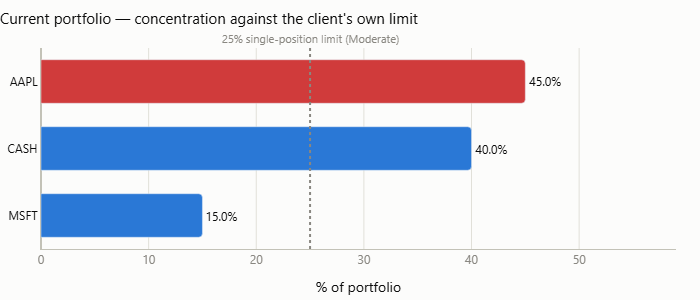

In [6]:
# --- Chart theme -----------------------------------------------------------
# Palette from the validated categorical set (blue / orange / aqua), which
# clears the CVD and normal-vision separation gates; every bar also carries a
# direct label so identity never rests on colour alone.
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
CRITICAL = "#d03b3b"

def style(fig, title, height=360, xtitle=None):
    fig.update_layout(
        title=dict(text=title, font=dict(size=15, color=INK), x=0, xanchor="left"),
        paper_bgcolor=SURFACE, plot_bgcolor=SURFACE,
        font=dict(family="system-ui, -apple-system, Segoe UI, sans-serif",
                  size=12, color=INK),
        margin=dict(l=8, r=24, t=48, b=36), height=height, showlegend=False,
        xaxis=dict(title=xtitle, gridcolor=GRID, zerolinecolor=BASELINE,
                   linecolor=BASELINE, tickfont=dict(color=INK_MUTED)),
        yaxis=dict(gridcolor="rgba(0,0,0,0)", linecolor=BASELINE,
                   tickfont=dict(color=INK)),
        bargap=0.35,
    )
    return fig

def save(fig, name, width=900, height=None):
    fig.write_image(SHOTS / f"{name}.png", width=width,
                    height=height or fig.layout.height, scale=2)
    return fig

# --- Concentration vs the client's own limit -------------------------------
conc = {k: v for k, v in diagnostics["concentration"].items() if v > 0}
conc = dict(sorted(conc.items(), key=lambda kv: kv[1]))
limit = 0.25  # Moderate tier single-position cap

fig = go.Figure()
fig.add_bar(
    y=list(conc), x=[v * 100 for v in conc.values()], orientation="h",
    marker=dict(color=[CRITICAL if (s != "CASH" and v > limit) else BLUE
                       for s, v in conc.items()],
                cornerradius=4),
    text=[f"{v * 100:.1f}%" for v in conc.values()],
    textposition="outside", textfont=dict(color=INK),
    hovertemplate="%{y}: %{x:.1f}% of portfolio<extra></extra>",
)
fig.add_vline(x=limit * 100, line=dict(color=INK_MUTED, width=2, dash="dot"),
              annotation_text="25% single-position limit (Moderate)",
              annotation_position="top", annotation_font=dict(color=INK_MUTED, size=11))
style(fig, "Current portfolio — concentration against the client's own limit",
      height=300, xtitle="% of portfolio")
fig.update_xaxes(range=[0, max(conc.values()) * 100 + 14])
save(fig, "01-diagnostics-concentration", height=300)
fig

## 5. Agent 2 — Market Regime

A hybrid node. It first computes **auditable, deterministic** macro signals from real price history
(12 index/credit/commodity tickers plus five ratio trends — small-cap vs large-cap, high-yield vs
investment-grade credit, defensives vs the broad market, and so on), then asks an LLM to classify
the regime *grounded strictly in those signals*.

On any LLM failure it falls back to `Volatile` at confidence 0.0 — never an optimistic default. The
deterministic signals below are computed either way, so the evidence trail exists regardless.

In [7]:
print(f"Regime     : {regime['regime_label']}  (confidence {regime['confidence']:.2f})")
print(f"Narrative  : {regime['narrative'][:400]}")
print()

signals = regime["supporting_signals"]
window = signals.get("window", {})
if window:
    print(f"Signal window: {window.get('start')} → {window.get('end')} "
          f"({window.get('trading_days')} trading days)")
print()
ratios = signals.get("ratio_trends", {})
def _split_name(name):
    # 'semis_vs_broad_market (SMH/SPY)' -> ('semis vs broad market', 'SMH/SPY')
    head, _, tail = name.partition(" (")
    return head.replace("_", " "), tail.rstrip(")")

rows = [{"Signal": _split_name(name)[0],
         "Pair": _split_name(name)[1],
         "Change %": d.get("pct_change"),
         "Trend": d.get("trend")}
        for name, d in ratios.items() if d.get("available")]
pd.DataFrame(rows)

Regime     : Volatile  (confidence 0.00)
Narrative  : LLM synthesis failed (LLMUnavailable: GEMINI_API_KEY is not configured (still the placeholder value). Agents will use their deterministic fallbacks.). Falling back to the safe default of 'Volatile' with confidence=0.0 -- this is NOT a real market assessment, it is a deliberate fail-safe so that downstream agents do not act on an unverified or fabricated regime call. See supporting_signals for the 

Signal window: 2026-01-26 → 2026-07-24 (126 trading days)



,Signal,Pair,Change %,Trend
0,small cap vs large cap,IWM/SPY,3.29,rising
1,high yield vs ig credit,HYG/LQD,2.65,rising
2,short vs long duration,SHY/TLT,4.31,rising
3,semis vs broad market,SMH/SPY,31.22,rising
4,defensives vs broad market,"avg(XLU,XLP)/SPY",-1.96,falling


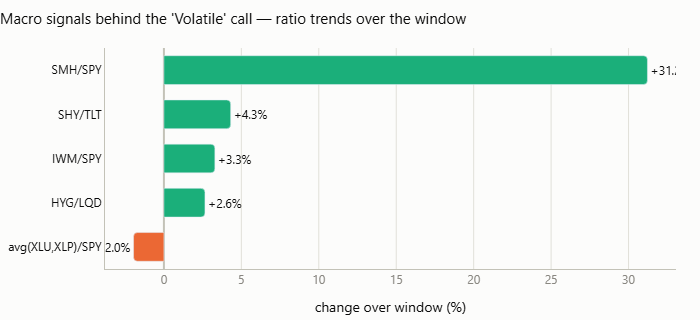

In [8]:
if rows:
    rdf = pd.DataFrame(rows).sort_values("Change %")
    fig = go.Figure()
    fig.add_bar(
        y=rdf["Pair"], x=rdf["Change %"], orientation="h",
        marker=dict(color=[AQUA if v >= 0 else ORANGE for v in rdf["Change %"]],
                    cornerradius=4),
        text=[f"{v:+.1f}%" for v in rdf["Change %"]],
        textposition="outside", textfont=dict(color=INK),
        customdata=rdf["Signal"],
        hovertemplate="%{customdata}<br>%{y}: %{x:+.2f}%<extra></extra>",
    )
    style(fig, f"Macro signals behind the '{regime['regime_label']}' call — "
               f"ratio trends over the window", height=320,
          xtitle="change over window (%)")
    save(fig, "02-market-regime-signals", height=320)
    display(fig)
else:
    print("No ratio signals available this run (market data was unavailable).")

## 6. Agent 3 — Stock Research

Screens a curated universe of ~34 large/mid-cap names across every sector. The screen is driven by
the **flaws Diagnostics found**, not by generic "cheap stock" criteria: an over-weighted sector
excludes that sector, a cash-drag flaw prefers dividend payers, a volatility flaw prefers low beta.
Survivors are then filtered on relative valuation (below-median P/E or P/B *within the filtered set*,
not an absolute magic number) and ranked.

Every candidate must name the specific flaw it addresses — a recommendation with no traceable reason
to exist doesn't get made.

In [9]:
cdf = pd.DataFrame([{
    "Ticker": c["ticker"],
    "Addresses flaw": (c["addresses_flaw"][:60] + "…") if len(c["addresses_flaw"]) > 60 else c["addresses_flaw"],
    "P/E": c["valuation_metrics"].get("pe_ratio"),
    "P/B": c["valuation_metrics"].get("price_to_book"),
    "Div yield %": c["valuation_metrics"].get("dividend_yield"),
    "Beta": c["valuation_metrics"].get("beta"),
    "Confidence": c["confidence"],
} for c in candidates])
print(f"{len(candidates)} candidates proposed")
cdf.round(2)

5 candidates proposed


,Ticker,Addresses flaw,P/E,P/B,Div yield %,Beta,Confidence
0,MCD,AAPL is 45.0% of the portfolio -- exceeds the ...,21.83,-146.28,2.81,0.42,0.0
1,ABBV,AAPL is 45.0% of the portfolio -- exceeds the ...,126.52,-68.85,2.67,0.28,0.0
2,JPM,AAPL is 45.0% of the portfolio -- exceeds the ...,15.13,2.66,1.70,0.98,0.0
3,XOM,AAPL is 45.0% of the portfolio -- exceeds the ...,26.47,2.56,2.63,0.16,0.0
4,CVX,AAPL is 45.0% of the portfolio -- exceeds the ...,33.88,2.10,3.66,0.49,0.0


## 7. Agents 4 & 5 — the guardrails

These run **in parallel** and neither can see the other's verdict:

- **Suitability** applies three deterministic rules — security quality (market cap ≥ $2B, listed on a
  major exchange, verifiable data), a near-retirement/short-horizon beta ceiling, and the risk-tier
  position cap — then sizes the survivors, distributing available cash by confidence weight and
  water-filling around each position's cap.
- **Tax-Awareness** checks each candidate against the client's transaction log for the 30-day
  wash-sale window, and reports embedded gains/losses on current holdings.

Because they run concurrently, **Suitability can approve and size a position that Tax-Awareness is
simultaneously flagging.** Reconciling that is the guardrail gate's job in the next section.

In [10]:
print("TAX-AWARENESS")
print(f"  wash-sale flags: {tax['wash_sale_flags'] or 'none'}")
for note in tax["tax_efficiency_notes"]:
    print(f"  • {note}")
print()
print("SUITABILITY")
print(f"  approved: {suitability['approved']}")
print(f"  violations recorded: {len(suitability['violations'])}")
for v in suitability["violations"]:
    print(f"  • {v}")

TAX-AWARENESS
  wash-sale flags: ['XOM', 'CVX']
  • XOM was sold within the last 30 days -- buying it back now would be a wash-sale violation and disallow any realized loss on the original sale. Consider waiting out the 30-day window before repurchasing, or evaluate a correlated-but-not-identical substitute security instead (specific substitute selection is Stock Research's job, not this check's).
  • CVX was sold within the last 30 days -- buying it back now would be a wash-sale violation and disallow any realized loss on the original sale. Consider waiting out the 30-day window before repurchasing, or evaluate a correlated-but-not-identical substitute security instead (specific substitute selection is Stock Research's job, not this check's).
  • AAPL carries an unrealized gain of $151,876.01 (81.8%) -- if Portfolio Diagnostics flags this position as over-concentrated, trimming it would trigger a taxable event worth planning around (e.g. tax-lot selection, spreading the sale across ta

## 8. The guardrail gate — where a finding becomes a refusal

This is the fix at the heart of the system's correctness. A compliance check that produces a flag
nobody acts on is not a compliance check. The gate takes Suitability's sized recommendations,
subtracts anything Tax-Awareness flagged, records why, and — if that leaves nothing — sends Stock
Research back for another pass with the rejected tickers excluded and the reasons attached.

In [11]:
if tax_blocked:
    print(f"Blocked by the wash-sale rule despite passing suitability: {', '.join(tax_blocked)}")
    print()
    for t in tax_blocked:
        print(f"  {t}: proposed by Stock Research, sized by Suitability, then withheld —")
        print(f"      the client sold it at a loss inside the 30-day window.")
    print()
    print("Without this reconciliation these names would have reached the client")
    print("with a dollar figure next to them, alongside a tax note warning against")
    print("buying exactly what was being recommended.")
else:
    print("No candidate collided with the wash-sale window on this run.")
    print("(The demo seeds recent loss-sales across the value/defensive cluster the")
    print(" screen usually favours; which names get proposed depends on live")
    print(" valuations on the day.)")

print()
print(f"Research passes used: {result['research_attempts'] + 1} (cap 3)")

Blocked by the wash-sale rule despite passing suitability: XOM, CVX

  XOM: proposed by Stock Research, sized by Suitability, then withheld —
      the client sold it at a loss inside the 30-day window.
  CVX: proposed by Stock Research, sized by Suitability, then withheld —
      the client sold it at a loss inside the 30-day window.

Without this reconciliation these names would have reached the client
with a dollar figure next to them, alongside a tax note warning against
buying exactly what was being recommended.

Research passes used: 1 (cap 3)


## 9. Final recommendations

In [12]:
# Dollar-valued holdings as the agents saw them, straight off the run state.
portfolio = result["client_profile"]["holdings"]
portfolio_value = sum(portfolio.values())
available_cash = portfolio.get("CASH", 0.0)

if recommendations:
    total = sum(r["allocation_amount"] for r in recommendations)
    print(f"{len(recommendations)} positions, ${total:,.0f} of ${available_cash:,.0f} "
          f"available cash deployed")
    if total < available_cash - 1:
        print(f"${available_cash - total:,.0f} left undeployed — the dollars earmarked for a")
        print("withheld candidate are not silently reassigned to the survivors. Re-sizing")
        print("is Suitability's job and only it knows the position caps, so the run")
        print("under-deploys rather than quietly over-concentrating what remains.")
    print()
    rdf2 = pd.DataFrame([{
        "Ticker": r["ticker"],
        "Allocation $": r["allocation_amount"],
        "% of portfolio": round(r["allocation_pct"] * 100, 2),
        "Addresses": r["addresses_flaw"][:70],
    } for r in recommendations])
    display(rdf2)
else:
    print("No candidate cleared every guardrail this cycle.")

3 positions, $180,000 of $300,000 available cash deployed
$120,000 left undeployed — the dollars earmarked for a
withheld candidate are not silently reassigned to the survivors. Re-sizing
is Suitability's job and only it knows the position caps, so the run
under-deploys rather than quietly over-concentrating what remains.



,Ticker,Allocation $,% of portfolio,Addresses
0,MCD,60000.0,8.0,AAPL is 45.0% of the portfolio -- exceeds the ...
1,ABBV,60000.0,8.0,AAPL is 45.0% of the portfolio -- exceeds the ...
2,JPM,60000.0,8.0,AAPL is 45.0% of the portfolio -- exceeds the ...


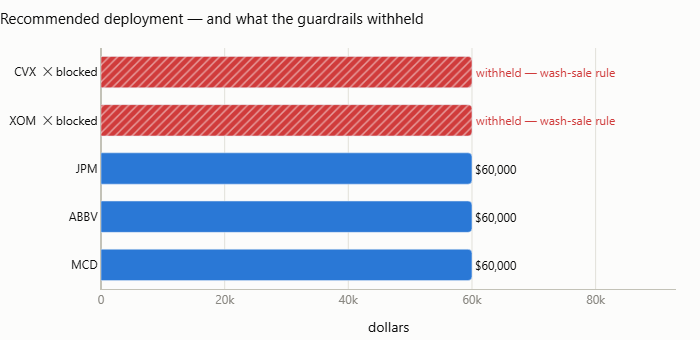

In [13]:
approved_names = [r["ticker"] for r in recommendations]
approved_amts = [r["allocation_amount"] for r in recommendations]

fig = go.Figure()
if approved_names:
    fig.add_bar(
        y=approved_names, x=approved_amts, orientation="h",
        marker=dict(color=BLUE, cornerradius=4),
        text=[f"${v:,.0f}" for v in approved_amts],
        textposition="outside", textfont=dict(color=INK),
        hovertemplate="%{y}: $%{x:,.0f} recommended<extra></extra>",
    )
if tax_blocked:
    # Blocked names are shown at the size they *would* have received, so the
    # refusal is visible rather than an absence. Status colour plus an
    # explicit label -- never colour alone.
    blocked_amt = (sum(approved_amts) / len(approved_amts)) if approved_amts else 0
    fig.add_bar(
        y=[f"{t}  ✕ blocked" for t in tax_blocked],
        x=[blocked_amt] * len(tax_blocked), orientation="h",
        marker=dict(color=CRITICAL, cornerradius=4,
                    pattern=dict(shape="/", fgcolor=SURFACE, size=6, solidity=0.25)),
        text=["withheld — wash-sale rule"] * len(tax_blocked),
        textposition="outside", textfont=dict(color=CRITICAL),
        hovertemplate="%{y}: withheld by the tax guardrail<extra></extra>",
    )
style(fig, "Recommended deployment — and what the guardrails withheld",
      height=340, xtitle="dollars")
fig.update_xaxes(range=[0, max(approved_amts + [1]) * 1.55])
save(fig, "03-recommendations", height=340)
fig

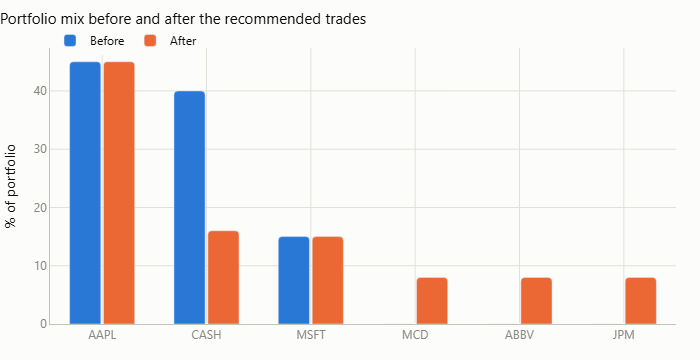

In [14]:
# Before/after portfolio mix, so the effect of the run is legible at a glance.
before_dollars = dict(portfolio)
after_dollars = dict(portfolio)
after_dollars["CASH"] = max(0.0, after_dollars.get("CASH", 0.0) - sum(approved_amts))
for r in recommendations:
    after_dollars[r["ticker"]] = after_dollars.get(r["ticker"], 0.0) + r["allocation_amount"]

order = sorted(after_dollars, key=lambda s: -after_dollars[s])
fig = go.Figure()
fig.add_bar(name="Before", x=order,
            y=[before_dollars.get(s, 0) / portfolio_value * 100 for s in order],
            marker=dict(color=BLUE, cornerradius=4),
            hovertemplate="%{x} before: %{y:.1f}%<extra></extra>")
fig.add_bar(name="After", x=order,
            y=[after_dollars[s] / portfolio_value * 100 for s in order],
            marker=dict(color=ORANGE, cornerradius=4),
            hovertemplate="%{x} after: %{y:.1f}%<extra></extra>")
style(fig, "Portfolio mix before and after the recommended trades", height=360,
      xtitle=None)
fig.update_layout(showlegend=True, barmode="group", bargroupgap=0.08,
                  legend=dict(orientation="h", y=1.08, x=0, font=dict(color=INK)),
                  yaxis=dict(title="% of portfolio", gridcolor=GRID,
                             linecolor=BASELINE, tickfont=dict(color=INK_MUTED)))
save(fig, "04-before-after", height=360)
fig

## 10. The audit trail

Every node writes a record: when it started, when it finished, whether it succeeded, and a one-line
summary. This is persisted to the `agent_runs` table by the API server and is the basis for
explaining any recommendation after the fact.

,Node,Status,Duration (s),Summary
0,portfolio_diagnostics,success,1.37,"Analyzed 3 holdings ($750,000 total); found 3 ..."
1,market_regime,error,3.19,LLM call failed; fell back to Volatile/0.0. Er...
2,stock_research,error,7.74,LLM ranking failed; deterministic fallback sel...
3,suitability,success,0.00,Evaluated 5 candidate(s): 5 approved with a to...
4,tax_awareness,success,0.01,Checked 5 candidate(s) against 5 recent sell(s...
5,finance_report,error,0.00,No GEMINI_API_KEY configured; used determinist...


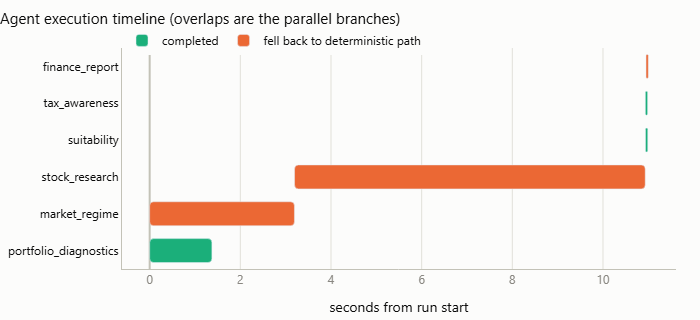

In [15]:
trail = result["audit_trail"]
tdf = pd.DataFrame([{
    "Node": r["node_name"],
    "Status": r["status"],
    "Duration (s)": round(
        (pd.Timestamp(r["completed_at"]) - pd.Timestamp(r["started_at"])).total_seconds(), 2
    ),
    "Summary": r["summary"][:90],
} for r in trail])
display(tdf)

t0 = min(pd.Timestamp(r["started_at"]) for r in trail)
fig = go.Figure()
seen = set()
for r in trail:
    s = (pd.Timestamp(r["started_at"]) - t0).total_seconds()
    e = (pd.Timestamp(r["completed_at"]) - t0).total_seconds()
    ok = r["status"] == "success"
    label = "completed" if ok else "fell back to deterministic path"
    fig.add_bar(y=[r["node_name"]], x=[max(e - s, 0.05)], base=[s], orientation="h",
                name=label, legendgroup=label, showlegend=label not in seen,
                marker=dict(color=AQUA if ok else ORANGE, cornerradius=4),
                hovertemplate=f"{r['node_name']}: {e - s:.2f}s — {label}<extra></extra>")
    seen.add(label)
style(fig, "Agent execution timeline (overlaps are the parallel branches)",
      height=320, xtitle="seconds from run start")
fig.update_layout(showlegend=True,
                  legend=dict(orientation="h", y=1.10, x=0, font=dict(color=INK)))
save(fig, "05-audit-timeline", height=320)
fig

## 11. The client-facing report

In [16]:
report = result["final_report"]
print(report)

WEALTH REPORT -- Client #1
(Risk tolerance: Moderate; time horizon: 20 years)

[Note: no Gemini API key is configured, so this report -- and the market regime call and stock ranking behind it -- were produced by the system's deterministic, non-AI fallbacks. Set GEMINI_API_KEY to enable the LLM-backed analysis.]

1. PORTFOLIO HEALTH CHECK
- Sharpe ratio: 1.53
- Annualized return: 36.3%
- Annualized volatility: 21.1%
- Diversification score: 61.5/100

Specific issues identified in your current portfolio:
  * AAPL is 45.0% of the portfolio -- exceeds the 25.0% concentration limit for a Moderate risk tolerance
  * CASH is 40.0% of the portfolio -- too much cash drag for a Moderate risk tolerance (threshold 30.0%)
  * Technology sector is 100.0% of non-cash holdings -- exceeds the 50.0% sector concentration threshold

2. MARKET CONTEXT
- Current regime classification: Volatile (confidence: 0.0%)
- Narrative: LLM synthesis failed (LLMUnavailable: GEMINI_API_KEY is not configured (still the p

## 12. Summary

What this run demonstrated:

| | |
|---|---|
| **Agents executed** | 6, across parallel branches with two fan-in points |
| **Data** | live prices and fundamentals; no mocks |
| **Diagnosis** | flaws scored against *this* client's risk tier, not fixed thresholds |
| **Refusals** | suitability rejections and wash-sale blocks, each with a stated reason |
| **Human-in-the-loop** | a genuine LangGraph interrupt, durably checkpointed and resumed |
| **Auditability** | every node's start, end, status and summary recorded |

To run the same flow through the HTTP API and the dashboard instead:

```bash
uvicorn server:app --reload      # API on :8000
solara run app.py                # dashboard on :8765
```